In [1]:
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
from PIL import Image
import os

In [2]:
def rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [3]:
def drawRotateRectCV( img, rotateRect, color = (0,122,255), thickness= 5):
    points = cv2.boxPoints(rotateRect)
    for i in range(0,4):
        cv2.line(img, [int(points[i][0]), int(points[i][1])], [int(points[(i+1)%4][0]), int(points[(i+1)%4][1])], 
                    color, thickness=thickness)

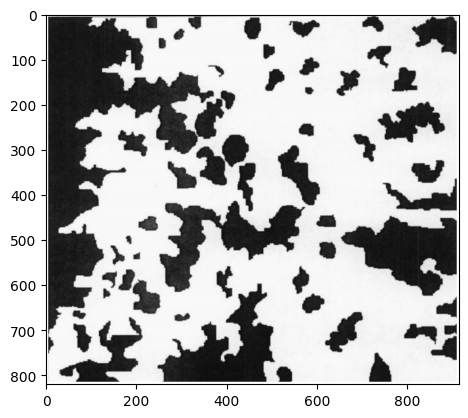

In [16]:
# _path = r'C:\Users\hp\Desktop\blister\pseudo_color_prediction\27.png'
_path = r'C:\Users\hp\Desktop\rust_std\Ri5.jpg'
img = cv2.imread(_path)
new_img = np.ones((10+img.shape[0], 10+img.shape[1], 3), dtype=np.uint8)*255
new_img[5:5+img.shape[0], 5:5+img.shape[1], :] = img
img = new_img
plt.imshow(rgb(img))

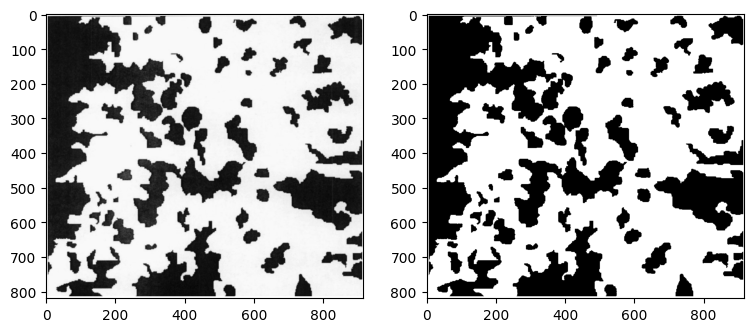

In [17]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, img_binary = cv2.threshold(img_gray, 200, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(9,18))
plt.subplot(1,2,1)
plt.imshow(img_gray, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(img_binary, cmap='gray')

In [18]:
_bli = (img_binary.shape[0]*img_binary.shape[1]-np.count_nonzero(img_binary))
print(_bli)
area_ratio = float(_bli)/ float(img_binary.shape[0]*img_binary.shape[1])
print(area_ratio)

273644
0.3643146234955799


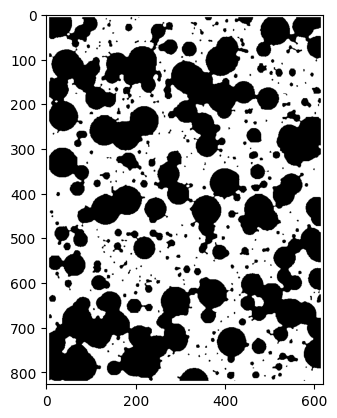

In [58]:
se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
img_se = cv2.morphologyEx(img_binary, cv2.MORPH_DILATE, se)
plt.imshow(img_se, cmap='gray')

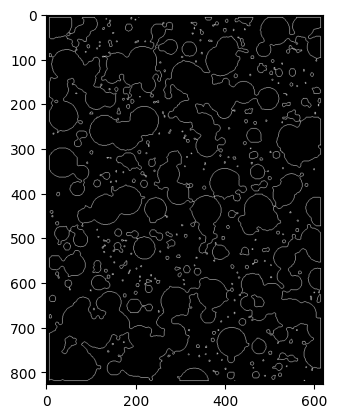

In [59]:
# img2 = cv2.Laplacian(img_binary, -1)
img2 = cv2.Laplacian(img_se, -1)
plt.imshow(img2, cmap='gray')
plt.show()

In [60]:
#找轮廓并发现最大轮廓
index_tune = 0
contours, hierarchy	= cv2.findContours(img2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
# contours, hierarchy	= cv2.findContours(img2, cv2.RETR_FLOODFILL, cv2.CHAIN_APPROX_NONE)

# contours = np.array(contours, dtype=object) #轮廓的长度不一样，无法表示为一个固定大小的numpy数组
contours_size = np.array([cv2.contourArea(s) for s in contours ])
sort_index = np.argsort(-contours_size) #返回从大到小的索引,降序排列
idx = sort_index[index_tune] #取一个轮廓，按t增加索引

In [55]:
print('max area: ', contours_size[sort_index[0]])
print(len(contours))
print(np.sum(contours_size))
print(np.sum(contours_size)/ float(img_binary.shape[0]*img_binary.shape[1]))

max area:  36922.5
175
170888.5
0.3332849007294145


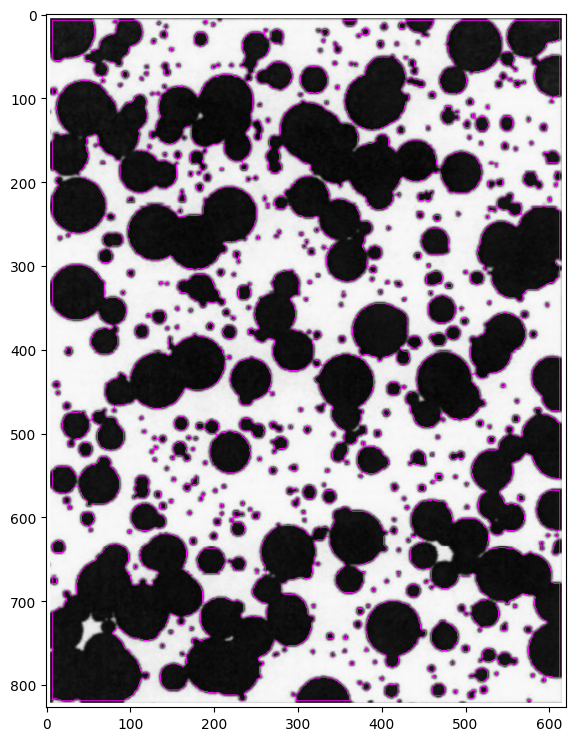

In [61]:
_img_copy = img.copy()
for _i in range(len(contours)):
    cv2.drawContours(_img_copy, contours, _i, (255,0,255), thickness=1) #画原轮廓
plt.figure(figsize=(9,9))
plt.imshow(rgb(_img_copy))

0.00029540061950683594
(1949, 1, 2)
((211.94679260253906, 715.6356201171875), (211.22276306152344, 435.18695068359375), 81.68683624267578)
0.000986337661743164
42747.5 206.75468555754668
0.083370714


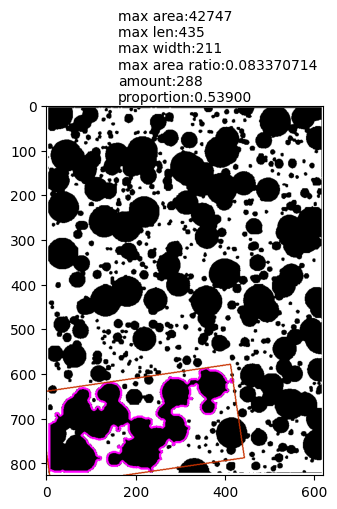

In [62]:
contour = contours[sort_index[0]]
t1 = time.time()
# poly = cv2.approxPolyDP(contour, 0.1, True) #多边形拟合
poly = contour
print(time.time()-t1)
print(poly.shape)
src_img = np.ones_like(img, dtype=np.uint8)*255
src_img[img_binary==0] = (0, 0, 0)
cv2.drawContours(src_img, [poly], 0, (255,0,255), thickness=3) #画原轮廓

rr = cv2.minAreaRect(poly)
print(rr)
drawRotateRectCV(src_img, rr, color=(0,50, 200), thickness=2)

t1 = time.time()
_a = cv2.contourArea(poly)
print(time.time()-t1)
print(_a, np.math.sqrt(_a))
_lw_index=[0, 1]
if rr[1][0]<rr[1][1]:
    _lw_index = [1, 0]
_max_str = [str(int(_a)), str(int(rr[1][_lw_index[0]])), str(int(rr[1][_lw_index[1]]))]

max_ratio = _a/(src_img.shape[0]*src_img.shape[1])
print('{:.9f}'.format(max_ratio))
plt.imshow(cv2.cvtColor(src_img, cv2.COLOR_BGR2RGB))
plt.text(160, -10, 
         'max area:'+_max_str[0]+'\n'+'max len:'+_max_str[1]+'\n'+'max width:'+_max_str[2]+'\n'+
         'max area ratio:'+'{:.9f}'.format(max_ratio) + '\n'
         +'amount:'+str(len(sort_index))+'\n'
         +'proportion:'+str(area_ratio)[:7] )
plt.show()

In [66]:
def deal_all(img_path, name, save_path):
    path = os.path.join(img_path, name)
    img = cv2.imread(path)
    new_img = np.ones((10+img.shape[0], 10+img.shape[1], 3), dtype=np.uint8)*255
    new_img[5:5+img.shape[0], 5:5+img.shape[1], :] = img
    img = new_img
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, img_binary = cv2.threshold(img_gray, 200, 255, cv2.THRESH_BINARY)
    
    _bli = (img_binary.shape[0]*img_binary.shape[1]-np.count_nonzero(img_binary))
    area_ratio = float(_bli)/ float(img_binary.shape[0]*img_binary.shape[1])
    if area_ratio > 0.35:
        se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        img_binary = cv2.morphologyEx(img_binary, cv2.MORPH_DILATE, se)

    img2 = cv2.Laplacian(img_binary, -1)

    contours, hierarchy	= cv2.findContours(img2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    # contours, hierarchy	= cv2.findContours(img2, cv2.RETR_FLOODFILL, cv2.CHAIN_APPROX_NONE)
    contours_size = np.array([cv2.contourArea(s) for s in contours ])
    sort_index = np.argsort(-contours_size) #返回从大到小的索引,降序排列

    contour = contours[sort_index[0]]
    poly = contour
    src_img = np.ones_like(img, dtype=np.uint8)*255
    src_img[img_binary==0] = (0, 0, 0)
    cv2.drawContours(src_img, [poly], 0, (255,0,255), thickness=3) #画原轮廓

    rr = cv2.minAreaRect(poly)
    drawRotateRectCV(src_img, rr, color=(0,50, 200), thickness=2)
    _a = cv2.contourArea(poly)
    _lw_index=[0, 1]
    if rr[1][0]<rr[1][1]:
        _lw_index = [1, 0]
    _max_str = [str(int(_a)), str(int(rr[1][_lw_index[0]])), str(int(rr[1][_lw_index[1]]))]

    max_ratio = _a/(src_img.shape[0]*src_img.shape[1])
    area_count_ratio = float(_bli)/len(sort_index)
    # plt.ylim(900, -100)
    plt.imshow(cv2.cvtColor(src_img, cv2.COLOR_BGR2RGB))
    
    plt.text(160, -10, 
            'max area:'+_max_str[0]+'\n'+'max len:'+_max_str[1]+'\n'+'max width:'+_max_str[2]+'\n'+
            'max area ratio:'+'{:.9f}'.format(max_ratio) + '\n'+
            'area_count_ratio:'+'{:.9f}'.format(area_count_ratio) + '\n'
            +'amount:'+str(len(sort_index))+'\n'
            +'proportion:'+str(area_ratio)[:7] )
    # plt.imsave(os.path.join(save_path, name.split('.')[0]+'.png'), src_img)
    
    plt.savefig(os.path.join(save_path, name.split('.')[0]+'.png'),bbox_inches='tight', dpi=150)
    plt.cla()

In [67]:
_path = r'C:\Users\hp\Desktop\blister_binary'
save_path = r'C:\Users\hp\Desktop\blister_std'
name_list = []
for item in os.listdir(_path):
    if item.split('.')[-1] == 'jpg':
        name_list.append(item)

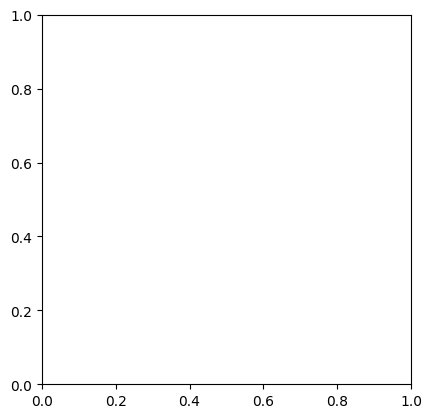

In [68]:
for name in name_list:
    deal_all(_path, name, save_path)